In [1]:
"""
Solution for week 12 practice in Data Visualization

Some examples of numerical computations on numpy arrays
https://scipy-lectures.org/intro/numpy/operations.html
"""

import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# create dictionaries to store Python list and numpy arrays
PY_LISTS = {}
NP_ARRAYS = {}

In [3]:
# Creation
def make_py_list(size):
    """
    Input: integer size of desired list
    
    Action: computed list of given size and save result in PY_LISTS
    Note that range alone does not create the list
    """
    PY_LISTS[size] = list(range(size)) 

In [4]:
def make_np_array(size):
    """
    Input: integer size of desired array
    
    Action: compute numpy array of given size and save result in NP_ARRAYS
    """
    NP_ARRAYS[size] = np.linspace(0, size - 1, size)
    
    

In [5]:
# Reduction    
def max_py_list(size):
    """
    Input: integer size
    
    Action: compute list comprehensive consisting of doubled elements
    """
    max(PY_LISTS[size])

In [6]:
def max_np_array(size):
    """
    Input: integer size
    
    Action: compute numpy array consisting of doubled elements
    """
    np.max(NP_ARRAYS[size])

In [7]:
# Vector operations
def double_py_list(size):
    """
    Input: integer size
    
    Action: compute list comprehensive consisting of doubled elements
    """
    [2 * elem for elem in PY_LISTS[size]]

In [8]:
def double_np_array(size):
    """
    Input: integer size
    
    Action: computed numpy array consisting of doubled elements
    """
    2 * NP_ARRAYS[size]
    
    

In [9]:
# Vector operations with broadcasting
def square_py_list(size):
    """
    Input: integer size
    
    Action: compute list comprehensive consisting of squared elements
    """
    [elem ** 2 for elem in PY_LISTS[size]]

In [10]:
def square_np_array(size):
    """
    Input: integer size
    
    Action: computed numpy array consisting of squared elements
    """
    NP_ARRAYS[size] ** 2

In [11]:
# Custom vector operations
scalar_abs = lambda x: x if x > 0 else -x
vector_abs = np.vectorize(scalar_abs)
    
def scalar_py_list(size):
    """
    Input: integer size
    
    Action: compute list comprehensive consisting of scalar_abs() applied to elements
    """
    [scalar_abs(elem) for elem in PY_LISTS[size]]

In [12]:
def vector_np_array(size):
    """
    Input: integer size
    
    Action: computed numpy array consisting of vector_abs() applied to array
    """
    vector_abs(NP_ARRAYS[size])
    

In [13]:
# Plotting code
def plot_comparison(test_funs, size_range, title="List vs. array - efficiency"):
    """
    Input: list test_funs whose elements are functions that takes an integer as input,
    range size_range
    
    Action: plots timings for functions in test_funs for given sizes
    """
    
    fig, axs = plt.subplots()
    for test_fun in test_funs:
        times = []
        for size in size_range:
            begin_time = time.perf_counter()
            test_fun(size)
            end_time = time.perf_counter()
            times.append(end_time - begin_time)
        axs.plot(size_range, times, label=str(test_fun.__name__) + "()")
    
    axs.set_xlabel("Sizes of input")
    axs.set_ylabel("Operation running times")
    axs.set_title(title)
    axs.legend()
    return fig

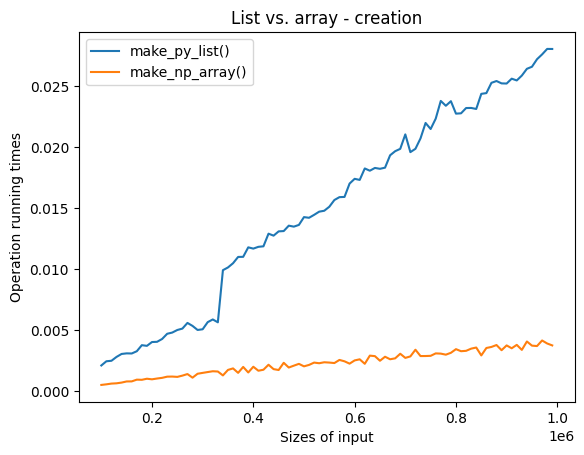

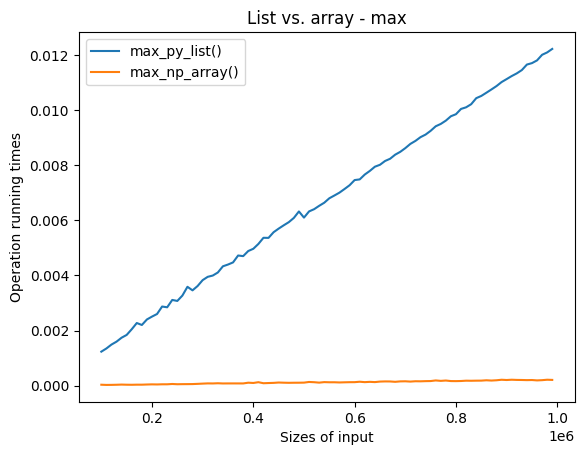

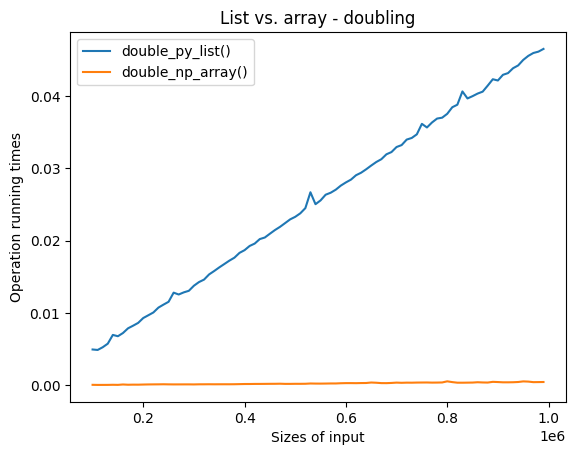

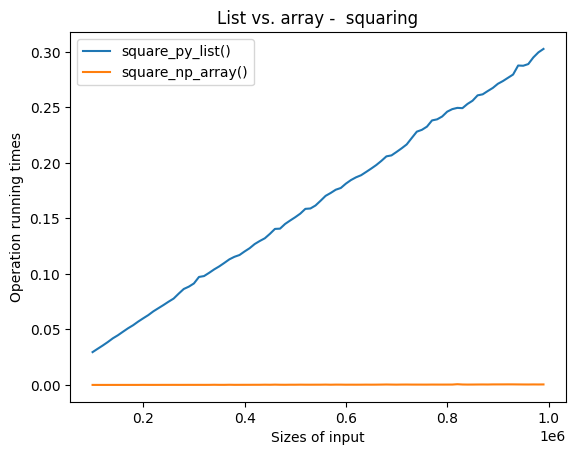

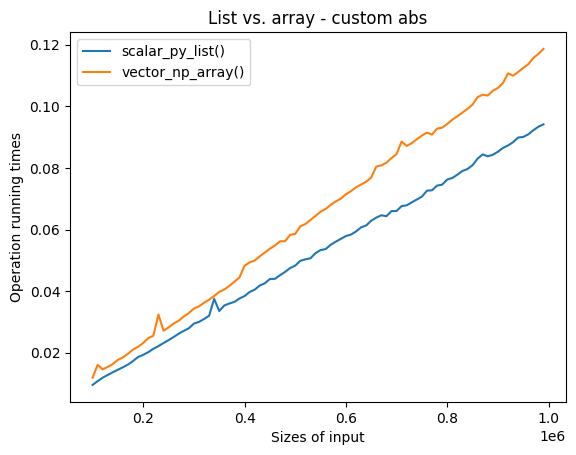

In [14]:
def run_comparisons():
    """ Run some comparisons of lists vs. arrays for various operations """
    
    size_range = list(range(100000, 1000000, 10000))
    plot_comparison([make_py_list, make_np_array], size_range, "List vs. array - creation") 
    plot_comparison([max_py_list, max_np_array], size_range, "List vs. array - max")
    plot_comparison([double_py_list, double_np_array], size_range, "List vs. array - doubling")
    plot_comparison([square_py_list, square_np_array], size_range, "List vs. array -  squaring")
    plot_comparison([scalar_py_list, vector_np_array], size_range, "List vs. array - custom abs")


run_comparisons()

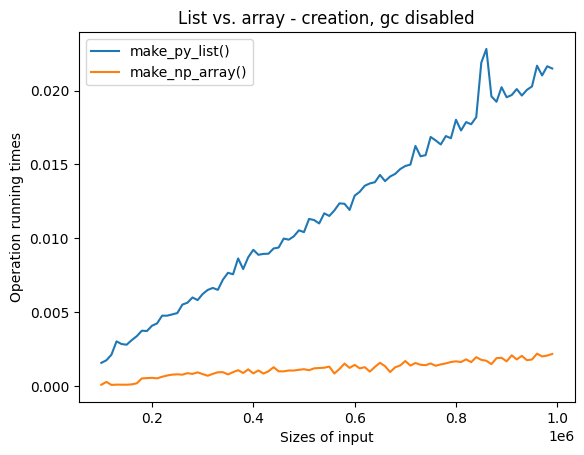

In [15]:
import gc

def run_comparison_no_gc():
    """ Run a comparison of lists vs. arrays with garbage collection off """
    gc.disable()
    plot_comparison([make_py_list, make_np_array], list(range(100000, 1000000, 10000)), 
                    "List vs. array - creation, gc disabled")
    
run_comparison_no_gc()